In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
import pickle

In [2]:
df = pd.read_excel('final.xlsx')
df.head()

,size,color,clarity,range,id,cut,symmetry,polish,fluor_intensity,depth_percent,table_percent,ratio,girdle_min,girdle_max,culet_size,total_sales_price
0,0.30,M,SI2,0.30-0.39,0.30-0.39MSI2,Very Good,Very Good,Excellent,Faint,64.0,57.0,1.009615,STK,TK,N,264
1,0.18,F,SI2,0.10-0.19,0.10-0.19FSI2,Very Good,Very Good,Very Good,None,63.3,60.0,1.008380,M,TK,N,284
2,0.18,I,SI1,0.10-0.19,0.10-0.19ISI1,Excellent,Excellent,Excellent,Faint,60.0,58.0,1.008130,TN,M,N,288
3,0.30,L,SI2,0.30-0.39,0.30-0.39LSI2,Excellent,Very Good,Excellent,None,60.2,59.0,1.006944,M,STK,N,298
4,0.19,J,VS2,0.10-0.19,0.10-0.19JVS2,Excellent,Excellent,Very Good,None,62.3,57.0,1.002695,M,STK,N,316


In [3]:
df.shape

(80102, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80102 entries, 0 to 80101
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   size               80102 non-null  float64
 1   color              80102 non-null  object 
 2   clarity            80102 non-null  object 
 3   range              80102 non-null  object 
 4   id                 80102 non-null  object 
 5   cut                80102 non-null  object 
 6   symmetry           80102 non-null  object 
 7   polish             80102 non-null  object 
 8   fluor_intensity    80102 non-null  object 
 9   depth_percent      80102 non-null  float64
 10  table_percent      80102 non-null  float64
 11  ratio              80102 non-null  float64
 12  girdle_min         80102 non-null  object 
 13  girdle_max         80102 non-null  object 
 14  culet_size         80102 non-null  object 
 15  total_sales_price  80102 non-null  int64  
dtypes: float64(4), int64(1

In [5]:
df.columns

Index(['size', 'color', 'clarity', 'range', 'id', 'cut', 'symmetry', 'polish',
       'fluor_intensity', 'depth_percent', 'table_percent', 'ratio',
       'girdle_min', 'girdle_max', 'culet_size', 'total_sales_price'],
      dtype='object')

In [6]:
df.describe()

,size,depth_percent,table_percent,ratio,total_sales_price
count,80102.000000,80102.000000,80102.000000,80102.000000,8.010200e+04
mean,0.601370,62.043837,57.836415,1.006320,5.156498e+03
std,0.601734,1.298575,1.791439,0.002746,2.011167e+04
min,0.150000,56.000000,52.000000,1.000000,2.640000e+02
25%,0.300000,61.300000,57.000000,1.004577,9.160000e+02
50%,0.400000,62.300000,58.000000,1.006116,1.314000e+03
75%,0.670000,62.800000,59.000000,1.007500,3.608000e+03
max,10.960000,65.500000,65.000000,1.037037,1.210692e+06


In [7]:
# REMOVING OUTLIERS
for i in df['id'].unique():
    temp_df = df[df['id']==i]
    avg_id = temp_df['total_sales_price'].mean()
    std_id = temp_df['total_sales_price'].std()
    for j in temp_df['total_sales_price']:
        if j < (avg_id - (3 * std_id)) or j > (avg_id + (3 * std_id)):
            df.drop( df[df['total_sales_price'] == j].index,axis=0,inplace=True)

In [8]:
df.shape

(70412, 16)

In [9]:
clarity_order = { 0 : 'IF', 1 : 'VVS1', 2 : 'VVS2', 3 : 'VS1', 4 : 'VS2', 5 : 'SI1', 6 : 'SI2', 7 : 'I1', 8 : 'I2', 9 : 'I3'}
cut_order = {0 : 'Excellent', 1 : 'Very Good'}
symmetry_order = {0 : 'Excellent', 1 : 'Very Good'}
polish_order = {0 : 'Excellent', 1 : 'Very Good'}
fluorescence_order = {0 : 'None', 1 : 'Faint', 2 : 'Medium', 3 : 'Strong', 4 : 'Very Strong'}
# girdle_max_order = {0 : 'XT', 1 : 'VTN', 2 : 'VTN', 3 : 'XTN', 4 : 'M',5 : 'TK',6 : 'STK',7 : 'VTK',8:'XTK'}
# girdle_min_order = {0 : 'TN', 1 : 'STN', 2 : 'VTN', 3 : 'XTN', 4 : 'M',5 : 'TK',6 : 'STK',7 : 'VTK',8:'XTK'}
culet_size_order = {0 : 'N', 1 : 'VS', 2 : 'S', 3 : 'M'}

In [10]:
df['clarity'].replace(to_replace=clarity_order.values(),value=clarity_order.keys(),inplace=True)
df['cut'].replace(to_replace=cut_order.values(),value=cut_order.keys(),inplace=True)
df['symmetry'].replace(to_replace=symmetry_order.values(),value=symmetry_order.keys(),inplace=True)
df['polish'].replace(to_replace=polish_order.values(),value=polish_order.keys(),inplace=True)
df['fluor_intensity'].replace(to_replace=fluorescence_order.values(),value=fluorescence_order.keys(),inplace=True)
# df['girdle_max'].replace(to_replace=girdle_max_order.values(),value=girdle_max_order.keys(),inplace=True)
# df['girdle_min'].replace(to_replace=girdle_min_order.values(),value=girdle_min_order.keys(),inplace=True)
df['culet_size'].replace(to_replace=culet_size_order.values(),value=culet_size_order.keys(),inplace=True)
df.head()

,size,color,clarity,range,id,cut,symmetry,polish,fluor_intensity,depth_percent,table_percent,ratio,girdle_min,girdle_max,culet_size,total_sales_price
0,0.30,M,6,0.30-0.39,0.30-0.39MSI2,1,1,0,1,64.0,57.0,1.009615,STK,TK,0,264
1,0.18,F,6,0.10-0.19,0.10-0.19FSI2,1,1,1,0,63.3,60.0,1.008380,M,TK,0,284
2,0.18,I,5,0.10-0.19,0.10-0.19ISI1,0,0,0,1,60.0,58.0,1.008130,TN,M,0,288
3,0.30,L,6,0.30-0.39,0.30-0.39LSI2,0,1,0,0,60.2,59.0,1.006944,M,STK,0,298
4,0.19,J,4,0.10-0.19,0.10-0.19JVS2,0,0,1,0,62.3,57.0,1.002695,M,STK,0,316


In [11]:
df.drop(['range','id'],axis=1,inplace=True)

In [12]:
df['ratio'] = round(df['ratio'],2)

In [13]:
df.head()

,size,color,clarity,cut,symmetry,polish,fluor_intensity,depth_percent,table_percent,ratio,girdle_min,girdle_max,culet_size,total_sales_price
0,0.30,M,6,1,1,0,1,64.0,57.0,1.01,STK,TK,0,264
1,0.18,F,6,1,1,1,0,63.3,60.0,1.01,M,TK,0,284
2,0.18,I,5,0,0,0,1,60.0,58.0,1.01,TN,M,0,288
3,0.30,L,6,0,1,0,0,60.2,59.0,1.01,M,STK,0,298
4,0.19,J,4,0,0,1,0,62.3,57.0,1.00,M,STK,0,316


In [14]:
lb = LabelEncoder()
df['color'] = lb.fit_transform(df['color'])
df['girdle_min'] = lb.fit_transform(df['girdle_min'])
df['girdle_max'] = lb.fit_transform(df['girdle_max'])

In [15]:
x = df.drop(['total_sales_price'],axis=1)
y = df['total_sales_price']

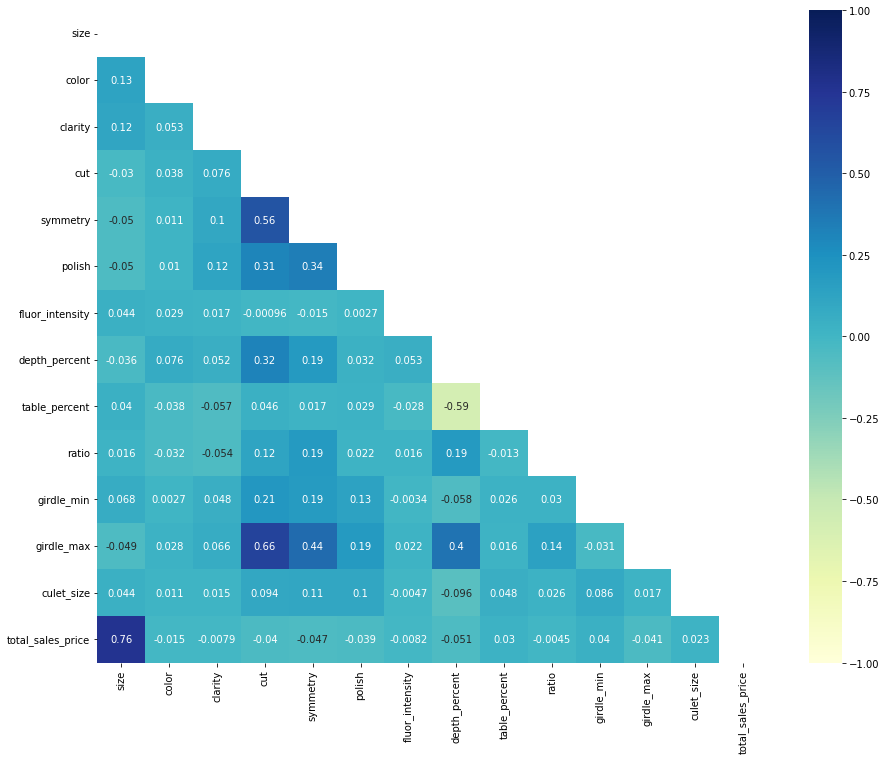

In [16]:
plt.figure(figsize=(15,12))
vmin = -1
center = 0
vmax = 1
mask = np.triu(np.ones_like(pd.concat([x,y],axis=1).corr()))
  
# plotting the heatmap
hm = sns.heatmap(pd.concat([x,y],axis=1).corr(),vmin=vmin,vmax=vmax,center=center, annot=True,cmap="YlGnBu",mask=mask)

### FOR POINTERS

In [17]:
ptr_df = df[df['size']<1]

In [18]:
ptr_df.head()

,size,color,clarity,cut,symmetry,polish,fluor_intensity,depth_percent,table_percent,ratio,girdle_min,girdle_max,culet_size,total_sales_price
0,0.30,9,6,1,1,0,1,64.0,57.0,1.01,1,3,0,264
1,0.18,2,6,1,1,1,0,63.3,60.0,1.01,0,3,0,284
2,0.18,5,5,0,0,0,1,60.0,58.0,1.01,4,0,0,288
3,0.30,8,6,0,1,0,0,60.2,59.0,1.01,0,1,0,298
4,0.19,6,4,0,0,1,0,62.3,57.0,1.00,0,1,0,316


In [19]:
ptr_df.shape

(56777, 14)

In [20]:
x = ptr_df.drop(['total_sales_price'],axis=1)
y = ptr_df['total_sales_price']

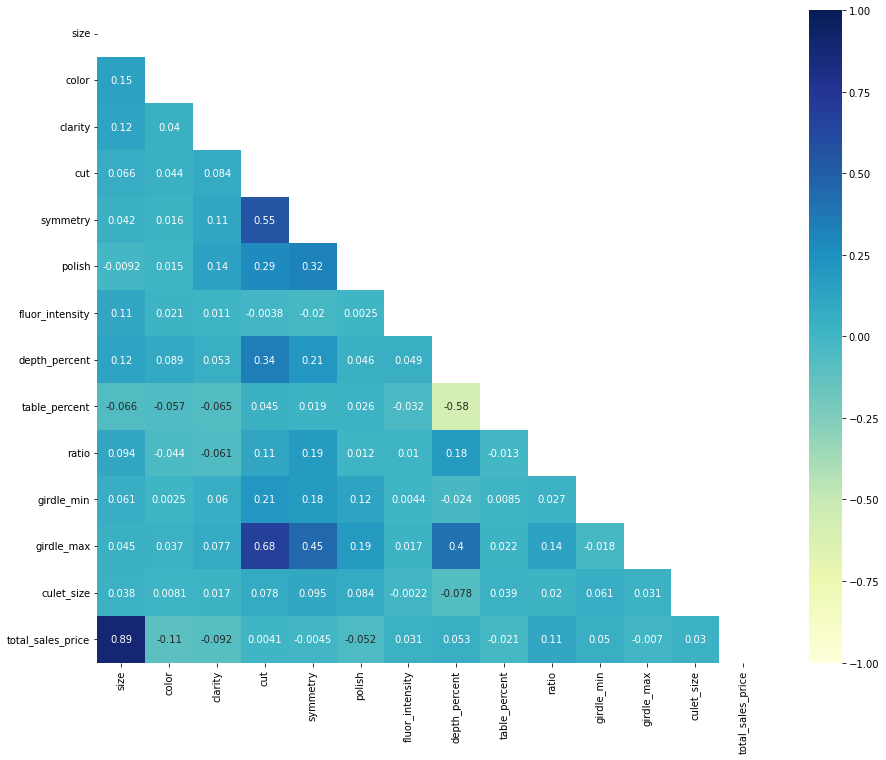

In [21]:
plt.figure(figsize=(15,12))
vmin = -1
center = 0
vmax = 1
mask = np.triu(np.ones_like(pd.concat([x,y],axis=1).corr()))
  
# plotting the heatmap
hm = sns.heatmap(pd.concat([x,y],axis=1).corr(),vmin=vmin,vmax=vmax,center=center, annot=True,cmap="YlGnBu",mask=mask)

In [22]:
y=np.array(y)

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.75,random_state=123)

In [24]:
n_estimators = [410]
max_features = ['auto']
max_depth = [8]
min_samples_split = [4]
min_samples_leaf = [2]
bootstrap = [True]

In [25]:
from sklearn.model_selection import RandomizedSearchCV
random_grid = {
    'n_estimators' : n_estimators,
    'max_features' : max_features,
    'max_depth' : max_depth,
    'min_samples_split' : min_samples_split,
    'min_samples_leaf' : min_samples_leaf,
    'bootstrap' : bootstrap
}

In [26]:
model = RandomForestRegressor()

In [27]:
ptr_model = RandomizedSearchCV(estimator = model,param_distributions=random_grid,n_iter=15,cv=3,verbose=2)

In [28]:
ptr_model.fit(x_train,y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END bootstrap=True, max_depth=8, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=410; total time=  18.5s
[CV] END bootstrap=True, max_depth=8, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=410; total time=  18.3s
[CV] END bootstrap=True, max_depth=8, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=410; total time=  17.8s


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_iter=15,
                   param_distributions={'bootstrap': [True], 'max_depth': [8],
                                        'max_features': ['auto'],
                                        'min_samples_leaf': [2],
                                        'min_samples_split': [4],
                                        'n_estimators': [410]},
                   verbose=2)

In [29]:
ptr_model.best_params_

{'n_estimators': 410,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_features': 'auto',
 'max_depth': 8,
 'bootstrap': True}

In [30]:
y_pred = ptr_model.predict(x_test)
y_pred

array([2494.03408794, 1701.90984209, 3556.69566716, ..., 1755.07565912,
       1204.28523516,  813.30654135])

In [31]:
print(f'Train Accuracy :{ptr_model.score(x_train,y_train):.3f}')
print(f'Test Accuracy :{ptr_model.score(x_test,y_test):.3f}')

Train Accuracy :0.979
Test Accuracy :0.977


In [32]:
mean_absolute_error(y_test,y_pred)

137.87052218478016

In [33]:
result1_df = pd.DataFrame({'Predicted Price': y_pred,'Actual Price':y_test})
result1_df.head(10) 

,Predicted Price,Actual Price
0,2494.034088,2462
1,1701.909842,1672
2,3556.695667,3432
3,970.387131,940
4,794.390120,708
5,692.898944,622
6,680.962728,666
7,984.920004,848
8,4420.707632,4343
9,860.335949,878


In [34]:
result1_df["Error % using RF"] = ((result1_df["Predicted Price"] - result1_df["Actual Price"]) / result1_df["Actual Price"]) *100
result1_df = result1_df.round(2)
result1_df.head(10)

,Predicted Price,Actual Price,Error % using RF
0,2494.03,2462,1.30
1,1701.91,1672,1.79
2,3556.70,3432,3.63
3,970.39,940,3.23
4,794.39,708,12.20
5,692.90,622,11.40
6,680.96,666,2.25
7,984.92,848,16.15
8,4420.71,4343,1.79
9,860.34,878,-2.01


In [35]:
data = {
        'Model': ['Random Forest Regression for Pointers'],
        'Mean' : np.round([result1_df['Error % using RF'].mean()],decimals=2),
        'Max'  : [result1_df['Error % using RF'].max()],
        'Min'  : [result1_df['Error % using RF'].min()],
        'Variance': np.round([result1_df['Error % using RF'].var()],decimals=2)
        }

model_stats = pd.DataFrame(data)
model_stats

,Model,Mean,Max,Min,Variance
0,Random Forest Regression for Pointers,1.32,68.8,-42.03,111.01


### FOR ONE-UPs

In [36]:
one_up_df = df[df['size'] >= 1]
one_up_df.head()

,size,color,clarity,cut,symmetry,polish,fluor_intensity,depth_percent,table_percent,ratio,girdle_min,girdle_max,culet_size,total_sales_price
56106,1.01,9,6,1,0,0,0,62.8,58.0,1.01,6,1,0,3132
56572,1.03,9,6,0,0,0,2,61.4,58.0,1.00,0,1,0,3204
56622,1.02,9,4,1,1,0,0,64.7,60.0,1.01,1,3,0,3213
56721,1.00,9,6,0,1,1,2,62.6,57.0,1.01,0,1,0,3221
56839,1.02,8,6,0,0,0,1,61.6,61.0,1.00,1,0,0,3232


In [37]:
one_up_df = one_up_df[one_up_df['size'] < 5]
one_up_df.head()

,size,color,clarity,cut,symmetry,polish,fluor_intensity,depth_percent,table_percent,ratio,girdle_min,girdle_max,culet_size,total_sales_price
56106,1.01,9,6,1,0,0,0,62.8,58.0,1.01,6,1,0,3132
56572,1.03,9,6,0,0,0,2,61.4,58.0,1.00,0,1,0,3204
56622,1.02,9,4,1,1,0,0,64.7,60.0,1.01,1,3,0,3213
56721,1.00,9,6,0,1,1,2,62.6,57.0,1.01,0,1,0,3221
56839,1.02,8,6,0,0,0,1,61.6,61.0,1.00,1,0,0,3232


In [38]:
one_up_df.shape

(13400, 14)

In [39]:
x = one_up_df.drop(['total_sales_price'],axis=1)
y = one_up_df['total_sales_price']

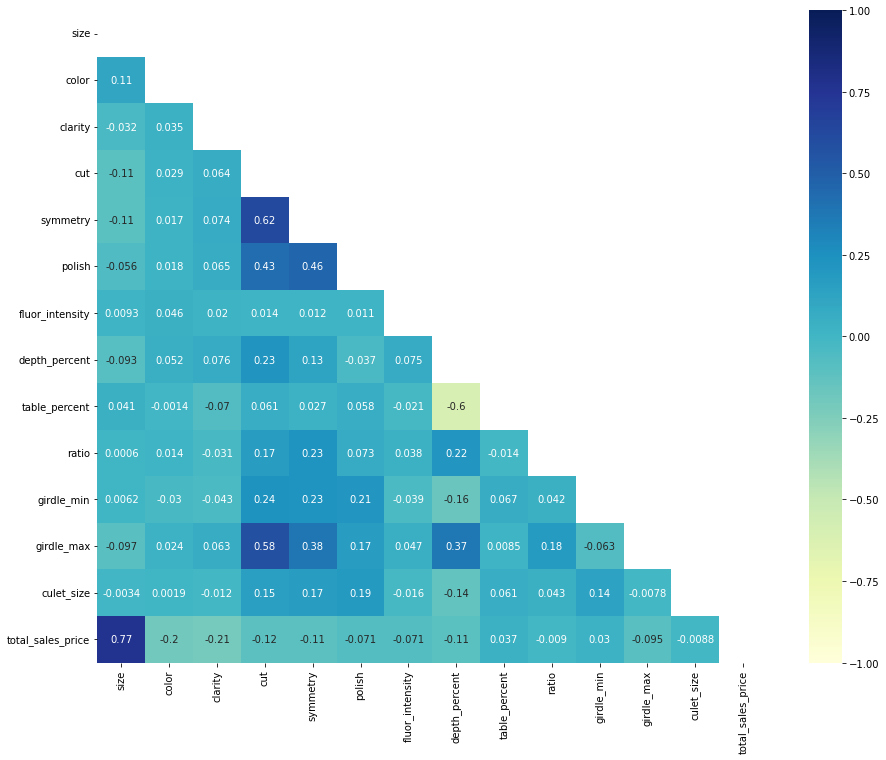

In [40]:
plt.figure(figsize=(15,12))
vmin = -1
center = 0
vmax = 1
mask = np.triu(np.ones_like(pd.concat([x,y],axis=1).corr()))
  
# plotting the heatmap
hm = sns.heatmap(pd.concat([x,y],axis=1).corr(),vmin=vmin,vmax=vmax,center=center, annot=True,cmap="YlGnBu",mask=mask)

In [41]:
y=np.array(y)

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.75,random_state=123)

In [43]:
n_estimators = [550]
max_features = ['auto']
max_depth = [9]
min_samples_split = [5]
min_samples_leaf = [2]
bootstrap = [True]

In [44]:
from sklearn.model_selection import RandomizedSearchCV
random_grid = {
    'n_estimators' : n_estimators,
    'max_features' : max_features,
    'max_depth' : max_depth,
    'min_samples_split' : min_samples_split,
    'min_samples_leaf' : min_samples_leaf,
    'bootstrap' : bootstrap
}

In [45]:
model = RandomForestRegressor()

In [46]:
one_up_model = RandomizedSearchCV(estimator = model,param_distributions=random_grid,n_iter=22,cv=5,verbose=2)

In [47]:
one_up_model.fit(x_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END bootstrap=True, max_depth=9, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=550; total time=   7.5s
[CV] END bootstrap=True, max_depth=9, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=550; total time=   7.6s
[CV] END bootstrap=True, max_depth=9, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=550; total time=   7.4s
[CV] END bootstrap=True, max_depth=9, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=550; total time=   7.5s
[CV] END bootstrap=True, max_depth=9, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=550; total time=   7.6s


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=22,
                   param_distributions={'bootstrap': [True], 'max_depth': [9],
                                        'max_features': ['auto'],
                                        'min_samples_leaf': [2],
                                        'min_samples_split': [5],
                                        'n_estimators': [550]},
                   verbose=2)

In [48]:
one_up_model.best_params_

{'n_estimators': 550,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'auto',
 'max_depth': 9,
 'bootstrap': True}

In [49]:
y_pred = one_up_model.predict(x_test)
y_pred

array([14408.86180216,  7221.57603954, 32743.37214891, ...,
        7273.46213427, 15201.60850517,  9144.67641832])

In [50]:
print(f'Train Accuracy :{one_up_model.score(x_train,y_train):.3f}')
print(f'Test Accuracy :{one_up_model.score(x_test,y_test):.3f}')

Train Accuracy :0.983
Test Accuracy :0.979


In [51]:
mean_absolute_error(y_test,y_pred)

1265.0811223693856

In [52]:
result2_df = pd.DataFrame({'Predicted Price': y_pred,'Actual Price':y_test})
result2_df.head(10) 

,Predicted Price,Actual Price
0,14408.861802,15399
1,7221.576040,7604
2,32743.372149,31856
3,14341.318582,13107
4,7426.545643,7560
5,16405.496951,16916
6,46839.878690,45147
7,18022.500201,18320
8,7509.394422,8109
9,4862.423550,5644


In [53]:
result2_df["Error % using RF"] = ((result2_df["Predicted Price"] - result2_df["Actual Price"]) / result2_df["Actual Price"]) *100
result2_df = result2_df.round(2)
result2_df.head(10)

,Predicted Price,Actual Price,Error % using RF
0,14408.86,15399,-6.43
1,7221.58,7604,-5.03
2,32743.37,31856,2.79
3,14341.32,13107,9.42
4,7426.55,7560,-1.77
5,16405.50,16916,-3.02
6,46839.88,45147,3.75
7,18022.50,18320,-1.62
8,7509.39,8109,-7.39
9,4862.42,5644,-13.85


In [54]:
data = {
        'Model': ['Random Forest Regression for One-Ups'],
        'Mean' : np.round([result2_df['Error % using RF'].mean()],decimals=2),
        'Max'  : [result2_df['Error % using RF'].max()],
        'Min'  : [result2_df['Error % using RF'].min()],
        'Variance': np.round([result2_df['Error % using RF'].var()],decimals=2)
        }

model_stats = pd.DataFrame(data)
model_stats

,Model,Mean,Max,Min,Variance
0,Random Forest Regression for One-Ups,1.38,72.43,-37.84,94.43


In [55]:
model1 = open('ptr_model1.pkl','wb')
pickle.dump(ptr_model,model1)
model1.close()

In [56]:
model2 = open('one_up_model1.pkl','wb')
pickle.dump(one_up_model,model2)
model2.close()